In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

100%|██████████| 82.0M/82.0M [00:01<00:00, 55.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2


In [2]:
from pathlib import Path

dataset_dir = Path(path)

# Посмотреть список всех файлов и папок внутри
for item in dataset_dir.iterdir():
    print(item.name)

one-indexed-files-notrash_val.txt
one-indexed-files-notrash_test.txt
zero-indexed-files.txt
Garbage classification
garbage classification
one-indexed-files.txt
one-indexed-files-notrash_train.txt


In [3]:
import os
from pathlib import Path
import torch
from torchvision import datasets, transforms

# 1. Указываем путь к папке с изображениями
# (выберите ту папку, где лежит структура карточек/классов)
images_path = os.path.join(path, "Garbage classification")

# 2. Определяем препроцессинг
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 3. Загружаем датасет
dataset = datasets.ImageFolder(root=images_path, transform=transform)
dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

print("Классы датасета:", dataset.classes)
print("Всего изображений:", len(dataset))

Классы датасета: ['Garbage classification']
Всего изображений: 2527


In [4]:
import os
from torchvision import datasets, transforms

# 1. Указываем путь сразу к папке, где непосредственно лежат категории
# Попробуйте один из следующих вариантов:
images_path = os.path.join(path, "Garbage classification", "Garbage classification")
# ИЛИ: images_path = os.path.join(path, "garbage classification")

# 2. Проверяем, какие папки там лежат
print("Подпапки категорий:", os.listdir(images_path))

# 3. Загружаем датасет
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=images_path, transform=transform)

print("Настоящие классы:", dataset.classes)
print("Всего изображений:", len(dataset))

Подпапки категорий: ['cardboard', 'paper', 'glass', 'trash', 'metal', 'plastic']
Настоящие классы: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Всего изображений: 2527


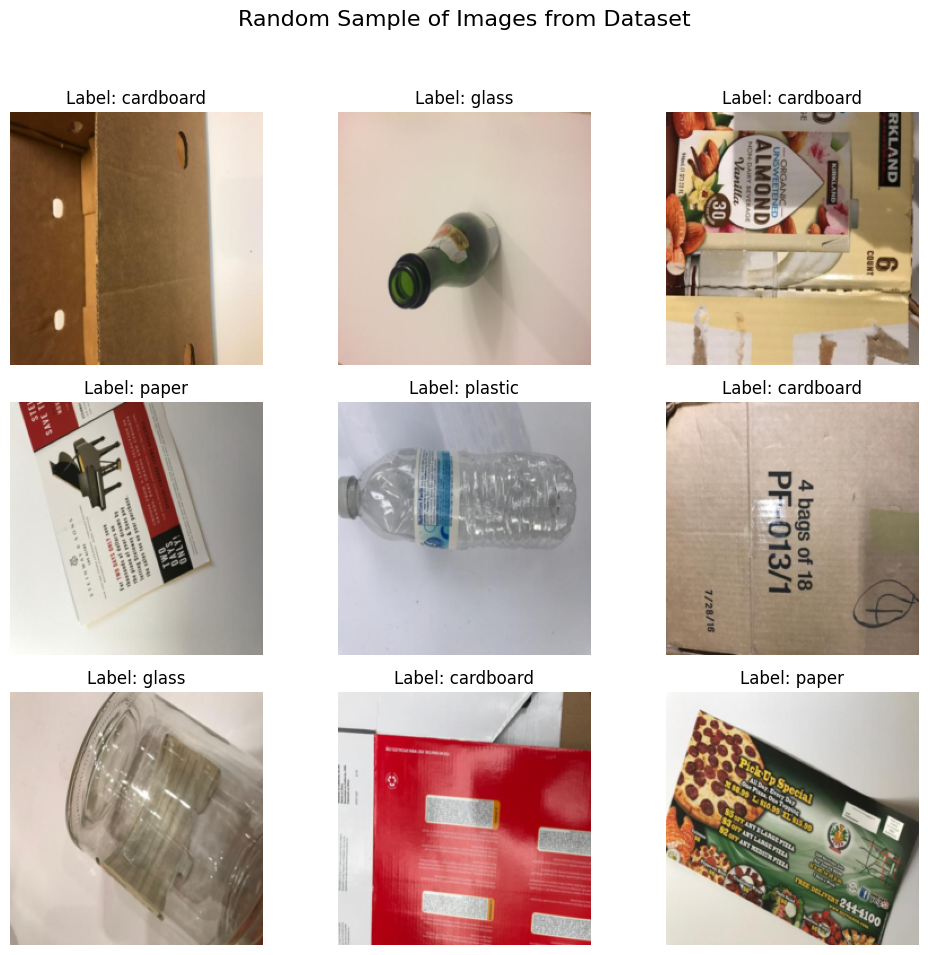

In [5]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Get class names and number of classes
class_names = dataset.classes
num_classes = len(class_names)

# Set up the figure size for better visualization
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Random Sample of Images from Dataset', fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Display 9 random images
for i in range(9):
    # Get a random index
    idx = random.randint(0, len(dataset) - 1)

    # Get the image and its label
    img, label = dataset[idx]

    # Convert the tensor image to a PIL Image for display
    # img is a tensor with shape (C, H, W), matplotlib expects (H, W, C)
    img = transforms.ToPILImage()(img)

    # Display the image
    axes[i].imshow(img)
    axes[i].set_title(f'Label: {class_names[label]}')
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

/tmp/ipykernel_1464/2089878382.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=class_counts, x='Класс', y='Количество', palette='viridis')


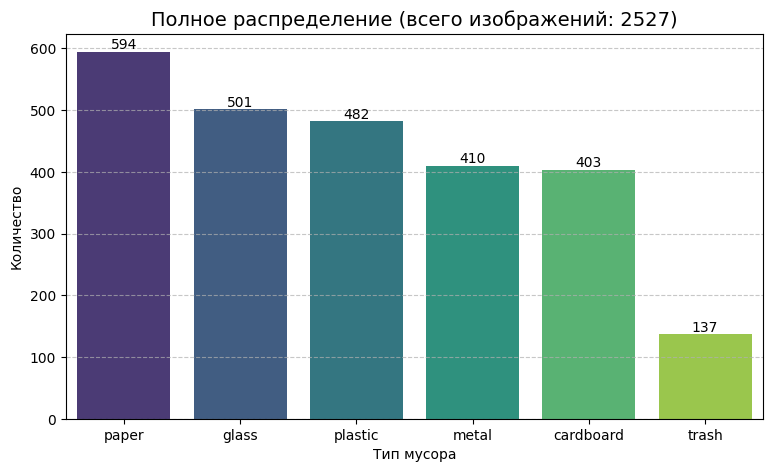

In [6]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Путь к папке, где непосредственно лежат папки категорий (glass, paper и т.д.)
# Укажите точный путь, где находятся 6 папок с классами
images_dir = Path(path) / "Garbage classification" / "Garbage classification"

# Собираем файлы из подпапок
data = []
for category_dir in images_dir.iterdir():
    if category_dir.is_dir():
        for img_file in category_dir.glob("*.*"):
            data.append({"path": str(img_file), "label": category_dir.name})

df_all = pd.DataFrame(data)

# Считаем количество
class_counts = df_all['label'].value_counts().reset_index()
class_counts.columns = ['Класс', 'Количество']

# Строим гистограмму
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=class_counts, x='Класс', y='Количество', palette='viridis')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title(f'Полное распределение (всего изображений: {len(df_all)})', fontsize=14)
plt.xlabel('Тип мусора')
plt.ylabel('Количество')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

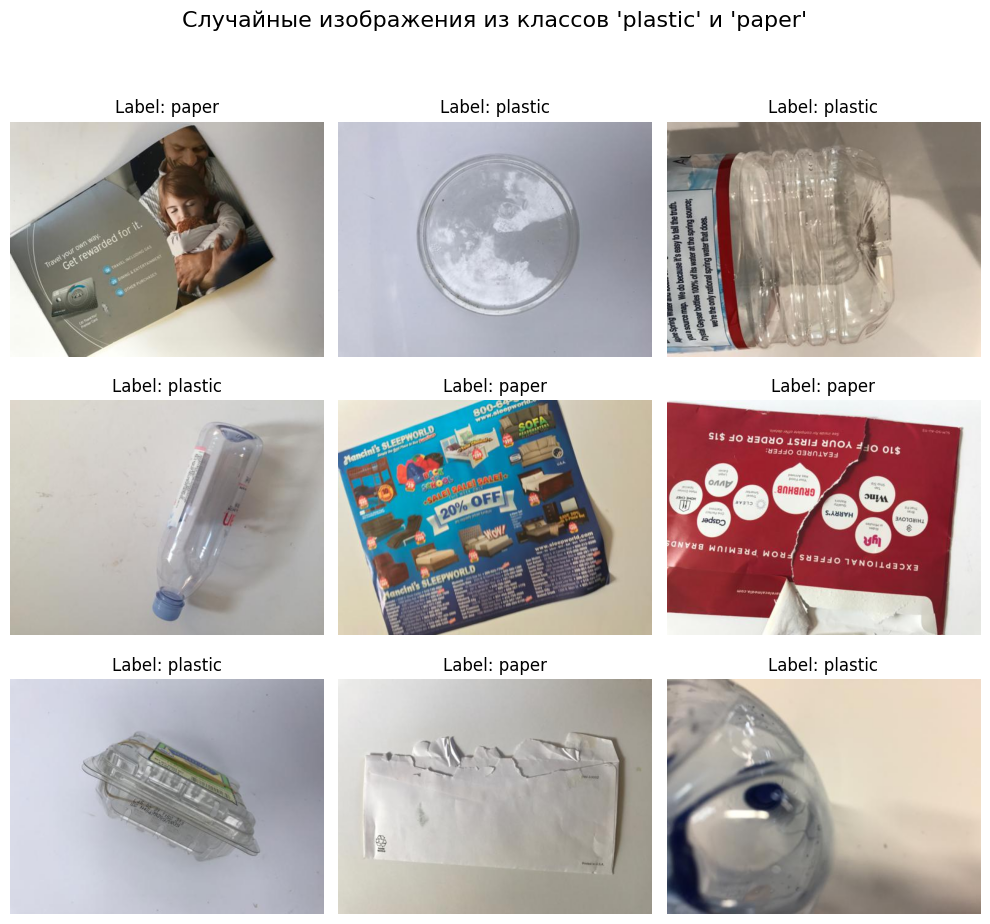

In [15]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Get class names (can reuse from previous cells or derive from df_filtered if needed)
class_names = df_filtered['label'].unique()

# Set up the figure size for better visualization
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('Случайные изображения из классов \'plastic\' и \'paper\'', fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

# Display 9 random images from df_filtered
for i in range(9):
    # Get a random image entry from the filtered DataFrame
    random_row = df_filtered.sample(n=1).iloc[0]
    img_path = random_row['path']
    label = random_row['label']

    # Open the image using PIL
    img = Image.open(img_path)

    # Display the image
    axes[i].imshow(img)
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

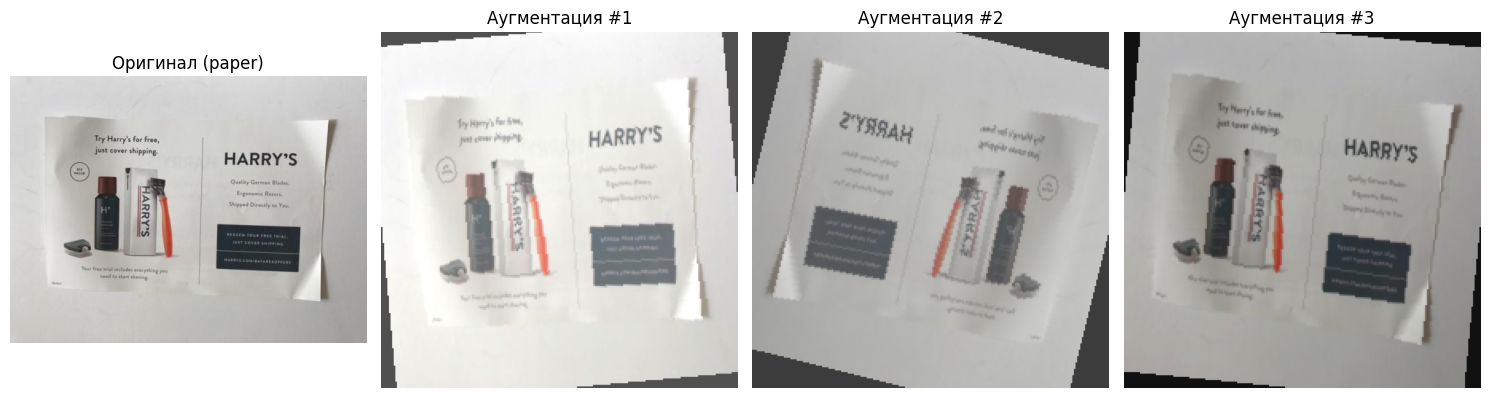

In [20]:
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# 1. Определяем цепочку аугментаций для обучения (Train Transforms)
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.3), # Усиливаем акцент на контрасте/бликах
    T.RandomAutocontrast(p=0.5)
])

# 2. Берем одну случайную картинку из вашего df_filtered
sample_row = df_filtered.sample(n=1).iloc[0]
orig_img = Image.open(sample_row['path'])
label = sample_row['label']

# 3. Сравниваем оригинал и 3 варианта аугментации
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Оригинал
axes[0].imshow(orig_img)
axes[0].set_title(f"Оригинал ({label})")
axes[0].axis('off')

# 3 случайных прогона через аугментацию
for i in range(1, 4):
    aug_img = train_transforms(orig_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Аугментация #{i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()